# Module 13 — Production

The distance between a notebook and a service is mostly not modelling. It is
persistence, versioning, input contracts, latency, monitoring and the plan for
what happens when the world changes.

A model that scores 0.78 and is monitored beats one that scores 0.80 and is
not, because the second one will silently be scoring 0.65 in nine months and
nobody will know.

### Learning objectives

1. Persist a model safely, with everything needed to reproduce and audit it.
2. Understand pickle's security and version-coupling problems, and the
   alternatives.
3. Measure and reduce inference latency.
4. Enforce an input contract at scoring time.
5. Detect covariate drift and concept drift, and tell them apart.
6. Design a monitoring and retraining strategy you could hand to an ops team.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

WORK = ROOT / "artifacts"
WORK.mkdir(exist_ok=True)

In [2]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

credit = load_credit_risk().sort_values("application_month").reset_index(drop=True)
FEATURES = [c for c in credit.columns if c not in {"default", "application_id", "collections_flag", "application_month"}]

# Train on the first two years; hold the third back to simulate "the future".
train_mask = credit["application_month"] < "2024-01"
X_train, y_train = credit.loc[train_mask, FEATURES], credit.loc[train_mask, "default"]
X_future, y_future = credit.loc[~train_mask, FEATURES], credit.loc[~train_mask, "default"]

prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)), ("sc", StandardScaler())]),
     make_column_selector(dtype_include=[np.number, "bool"])),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False))]),
     make_column_selector(dtype_include=["object", "string"])),
])
model = Pipeline([("prep", prep), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300, learning_rate=0.06))])
model.fit(X_train, y_train)

print(f"trained on {len(X_train):,} applications (2022-2023)")
print(f"holding back {len(X_future):,} (2024) to play the role of production traffic")

trained on 6,650 applications (2022-2023)
holding back 5,350 (2024) to play the role of production traffic


## 1. Persistence

### `joblib` — the default, and its two problems

In [3]:
import joblib

path_joblib = WORK / "model.joblib"
joblib.dump(model, path_joblib, compress=3)
print(f"model.joblib: {path_joblib.stat().st_size / 1e3:.1f} KB")

reloaded = joblib.load(path_joblib)
same = np.allclose(reloaded.predict_proba(X_future.head(200))[:, 1], model.predict_proba(X_future.head(200))[:, 1])
print("predictions identical after round-trip:", same)

model.joblib: 464.0 KB
predictions identical after round-trip: True


**Problem 1: pickle executes arbitrary code on load.** A `.joblib` or `.pkl`
file is a program, not data. Loading one from an untrusted source is
equivalent to running a script from that source. This is not theoretical —
malicious model files have been found on public model hubs.

**Problem 2: version coupling.** A pickle stores references to classes by
import path and the object's `__dict__`. Load it under a different
scikit-learn version and you get, in ascending order of unpleasantness: a
warning, an `AttributeError`, or **silently different predictions** because an
attribute the new version expects is missing and defaults differently.

The rule: **the loading environment must match the saving environment.** Pin
it, record it, and check it at load time.

In [4]:
import sklearn

print(f"pickle protocol : {joblib.__version__=}")
print("\nThe versions this artefact is coupled to:")
for mod in [sklearn, np, pd]:
    print(f"  {mod.__name__:<14} {mod.__version__}")

pickle protocol : joblib.__version__='1.5.3'

The versions this artefact is coupled to:
  sklearn        1.8.0
  numpy          2.4.4
  pandas         3.0.2


### `skops` — persistence without arbitrary code execution

`skops.io` serialises sklearn estimators to a format that can be **inspected
before loading** and that refuses unknown types unless you explicitly trust
them. For any model crossing a trust boundary, this is the right default.

In [5]:
import skops.io as sio

path_skops = WORK / "model.skops"
sio.dump(model, path_skops)
print(f"model.skops: {path_skops.stat().st_size / 1e3:.1f} KB")

# Inspect BEFORE loading: what types does this file want to construct?
untrusted = sio.get_untrusted_types(file=path_skops)
print("\ntypes not on the default trusted list:", untrusted or "(none — safe to load)")

loaded = sio.load(path_skops, trusted=untrusted)
print("predictions match joblib version:",
      np.allclose(loaded.predict_proba(X_future.head(100))[:, 1], model.predict_proba(X_future.head(100))[:, 1]))

model.skops: 2779.1 KB

types not on the default trusted list: ['numpy.dtype', 'numpy.number', 'sklearn.compose._column_transformer.make_column_selector']


predictions match joblib version: True


### ONNX — leaving Python behind

`skl2onnx` converts a fitted pipeline to the ONNX graph format, which runs in
C++, Java, C#, Rust or the browser via ONNX Runtime — typically 2–10× faster
than Python inference, with no scikit-learn dependency at serving time.

```python
from skl2onnx import to_onnx
onx = to_onnx(model, X_train.head(1).to_numpy().astype(np.float32))
(WORK / "model.onnx").write_bytes(onx.SerializeToString())

import onnxruntime as rt
sess = rt.InferenceSession(str(WORK / "model.onnx"))
proba = sess.run(None, {"X": batch.astype(np.float32)})[1]
```

The catch: not every estimator or transformer has a converter, and custom
estimators (Module 11) need one written by hand. Check converter coverage
*before* designing a pipeline you intend to export.

| Format | Safe to load untrusted | Cross-language | Version-coupled | Custom estimators |
|---|---|---|---|---|
| `joblib` / `pickle` | **no** | no | tightly | yes |
| `skops` | yes (with inspection) | no | loosely | yes, with a hook |
| `ONNX` | yes | **yes** | no | needs a converter |

## 2. What to save *besides* the model

A bare model file is not a deployable artefact. This is the minimum bundle,
and every field in it has answered a real incident somewhere.

In [6]:
import hashlib
import json
import platform
import subprocess
from datetime import datetime, timezone


def build_artifact(model, X_train, y_train, X_val, y_val, name, version, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    joblib.dump(model, out_dir / "model.joblib", compress=3)
    digest = hashlib.sha256((out_dir / "model.joblib").read_bytes()).hexdigest()

    p_val = model.predict_proba(X_val)[:, 1]

    # The input contract: what the service is allowed to receive.
    schema = {}
    for col in X_train.columns:
        s = X_train[col]
        spec = {"dtype": str(s.dtype), "nullable": bool(s.isna().any())}
        if pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s):
            spec |= {"min": float(s.min()), "max": float(s.max()),
                     "p01": float(s.quantile(0.01)), "p99": float(s.quantile(0.99)),
                     "mean": float(s.mean()), "std": float(s.std())}
        else:
            spec |= {"categories": sorted(map(str, s.dropna().unique()))[:60]}
        schema[col] = spec

    manifest = {
        "name": name,
        "version": version,
        "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "model_sha256": digest,
        "environment": {
            "python": platform.python_version(),
            "platform": platform.platform(),
            "scikit_learn": sklearn.__version__,
            "numpy": np.__version__,
            "pandas": pd.__version__,
        },
        "training": {
            "n_rows": int(len(X_train)),
            "n_features": int(X_train.shape[1]),
            "base_rate": float(y_train.mean()),
            "feature_order": list(X_train.columns),
        },
        "validation": {
            "n_rows": int(len(X_val)),
            "roc_auc": float(roc_auc_score(y_val, p_val)),
            "brier": float(brier_score_loss(y_val, p_val)),
            "mean_predicted": float(p_val.mean()),
            "observed_rate": float(np.mean(y_val)),
        },
        "decision": {
            "threshold": 0.13,
            "threshold_basis": "cost-optimal for C_FP=450, C_FN=6000 (Module 08)",
        },
        "schema": schema,
    }
    (out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2))

    # A reference batch: the ground truth for 'is this the same model?'
    ref = X_val.head(200)
    pd.DataFrame({"expected_proba": model.predict_proba(ref)[:, 1]}).to_csv(out_dir / "reference_predictions.csv", index=False)
    # JSON "table" orient round-trips dtypes exactly and stays human-readable,
    # which parquet does not and CSV cannot.
    ref.to_json(out_dir / "reference_inputs.json", orient="table")
    return manifest


manifest = build_artifact(model, X_train, y_train, X_future.head(3000), y_future.head(3000),
                          "consumer_default_risk", "1.0.0", WORK / "v1.0.0")

print(json.dumps({k: v for k, v in manifest.items() if k != "schema"}, indent=2)[:1400])

{
  "name": "consumer_default_risk",
  "version": "1.0.0",
  "created_utc": "2026-09-07T20:47:58+00:00",
  "model_sha256": "eb42c495b050d73b471e3594c571da428e8ac5efddad8477af62a3ff4cdb391f",
  "environment": {
    "python": "3.11.15",
    "platform": "Linux-6.18.44-fc-v24-x86_64-with-glibc2.39",
    "scikit_learn": "1.8.0",
    "numpy": "2.4.4",
    "pandas": "3.0.2"
  },
  "training": {
    "n_rows": 6650,
    "n_features": 16,
    "base_rate": 0.11473684210526315,
    "feature_order": [
      "age",
      "employment_years",
      "annual_income",
      "loan_amount",
      "term_months",
      "interest_rate",
      "debt_to_income",
      "credit_score",
      "n_open_accounts",
      "n_delinq_2yr",
      "home_ownership",
      "purpose",
      "employment_type",
      "region",
      "channel",
      "prior_customer"
    ]
  },
  "validation": {
    "n_rows": 3000,
    "roc_auc": 0.7638271023636878,
    "brier": 0.10293599775439137,
    "mean_predicted": 0.09521631110555583,
   

The **reference batch** is the piece people leave out and later wish they had.
It turns "did the deployment work?" from a judgement call into an assertion:
score the 200 reference rows and compare to the stored outputs. Any difference
means the environment, the artefact or the preprocessing changed.

In [7]:
def verify_deployment(artifact_dir, tolerance=1e-9):
    artifact_dir = Path(artifact_dir)
    manifest = json.loads((artifact_dir / "manifest.json").read_text())

    digest = hashlib.sha256((artifact_dir / "model.joblib").read_bytes()).hexdigest()
    checks = {"model_sha256_matches": digest == manifest["model_sha256"],
              "sklearn_version_matches": sklearn.__version__ == manifest["environment"]["scikit_learn"]}

    m = joblib.load(artifact_dir / "model.joblib")
    ref_in = pd.read_json(artifact_dir / "reference_inputs.json", orient="table")
    expected = pd.read_csv(artifact_dir / "reference_predictions.csv")["expected_proba"].to_numpy()
    got = m.predict_proba(ref_in)[:, 1]
    checks["reference_predictions_match"] = bool(np.abs(got - expected).max() < tolerance)
    checks["max_abs_deviation"] = float(np.abs(got - expected).max())
    return checks


for k, v in verify_deployment(WORK / "v1.0.0").items():
    print(f"  {k:<30} {v}")

  model_sha256_matches           True
  sklearn_version_matches        True
  reference_predictions_match    True
  max_abs_deviation              9.73613550891983e-17


## 3. Input contracts

In a notebook you control the input. In production, an upstream team renames a
column, changes an enum, or starts sending `-1` for missing. The model will not
raise — it will predict confidently on nonsense.

Validate against the schema you saved, and decide deliberately what happens on
violation: reject, clip, or flag.

In [8]:
class SchemaValidator:
    """Check incoming rows against the training-time schema."""

    def __init__(self, schema, feature_order):
        self.schema = schema
        self.feature_order = feature_order

    def validate(self, df: pd.DataFrame) -> dict:
        issues = []
        missing = set(self.feature_order) - set(df.columns)
        extra = set(df.columns) - set(self.feature_order)
        if missing:
            issues.append({"severity": "fatal", "detail": f"missing columns: {sorted(missing)}"})
        if extra:
            issues.append({"severity": "warn", "detail": f"unexpected columns (ignored): {sorted(extra)}"})

        for col, spec in self.schema.items():
            if col not in df.columns:
                continue
            s = df[col]
            if s.isna().any() and not spec["nullable"]:
                issues.append({"severity": "warn", "detail": f"{col}: nulls where training data had none"})
            if "min" in spec:
                if not pd.api.types.is_numeric_dtype(s):
                    issues.append({"severity": "fatal", "detail": f"{col}: expected numeric, got {s.dtype}"})
                    continue
                out_of_range = ((s < spec["p01"] - 3 * spec["std"]) | (s > spec["p99"] + 3 * spec["std"])).mean()
                if out_of_range > 0.01:
                    issues.append({"severity": "warn",
                                   "detail": f"{col}: {out_of_range:.1%} of values far outside the training range"})
            else:
                unseen = set(s.dropna().astype(str)) - set(spec["categories"])
                if unseen:
                    issues.append({"severity": "warn", "detail": f"{col}: unseen categories {sorted(unseen)[:5]}"})
        return {"ok": not any(i["severity"] == "fatal" for i in issues), "issues": issues}


validator = SchemaValidator(manifest["schema"], manifest["training"]["feature_order"])

print("clean batch:", validator.validate(X_future.head(500))["ok"])

# Now a batch with three realistic upstream failures.
broken = X_future.head(500).copy()
broken["annual_income"] = broken["annual_income"].fillna(-999)          # sentinel appears
broken.loc[broken.index[:40], "purpose"] = "crypto_investment"          # new enum value
broken = broken.rename(columns={"credit_score": "bureau_score"})        # column renamed upstream

result = validator.validate(broken)
print(f"\nbroken batch ok: {result['ok']}")
for issue in result["issues"]:
    print(f"  [{issue['severity']:>5}] {issue['detail']}")

clean batch: True

broken batch ok: False
  [fatal] missing columns: ['credit_score']
  [ warn] unexpected columns (ignored): ['bureau_score']
  [ warn] purpose: unseen categories ['crypto_investment']


> 💼 **Consulting lens.** Every one of those three failures is something a
> data-engineering change can cause on a Tuesday afternoon with no notice to
> the model owner. None of them raises an exception in scikit-learn — the
> sentinel is a valid float, the unseen category becomes all-zeros under
> `handle_unknown="ignore"`, and the rename would only fail because we fitted
> on a DataFrame. **The input contract is the model's only defence, and it has
> to be written by the model owner.**

## 4. Latency

Batch throughput and single-row latency are different problems with different
answers.

In [9]:
from time import perf_counter


def bench(model, X, n_repeat=5):
    out = {}
    for size in [1, 10, 100, 1000, 5000]:
        batch = X.head(size)
        model.predict_proba(batch)                      # warm-up: first call is slower
        t0 = perf_counter()
        for _ in range(n_repeat):
            model.predict_proba(batch)
        total_ms = (perf_counter() - t0) / n_repeat * 1000
        out[size] = {"batch_ms": round(total_ms, 3), "per_row_us": round(total_ms / size * 1000, 1)}
    return pd.DataFrame(out).T


lat = bench(model, X_future)
lat.index.name = "batch_size"
lat

,batch_ms,per_row_us
batch_size,,
1,8.587,8587.5
10,8.053,805.3
100,10.084,100.8
1000,21.147,21.1
5000,65.504,13.1


Per-row cost falls by two orders of magnitude from batch size 1 to 5,000. That
is **fixed overhead** — DataFrame construction, validation, the
`ColumnTransformer`'s column selection and hstack — amortised across rows.

The consequences for design:

- **Real-time single-row scoring is dominated by overhead, not by the model.**
  Tuning the model for speed is the wrong lever; removing per-call overhead is
  the right one.
- **Micro-batching** (collect 50 ms of requests, score together) can cut cost
  per prediction by 10× at the price of 50 ms of latency. Often a good trade.
- **Precompute what you can.** Feature lookups usually dominate model time.

In [10]:
# Where does the time actually go?
single = X_future.head(1)
model.predict_proba(single)

stages = {}
t0 = perf_counter()
for _ in range(200):
    Xt = model[:-1].transform(single)
stages["preprocessing"] = (perf_counter() - t0) / 200 * 1000

t0 = perf_counter()
for _ in range(200):
    model.named_steps["clf"].predict_proba(Xt)
stages["model"] = (perf_counter() - t0) / 200 * 1000

t0 = perf_counter()
for _ in range(200):
    model.predict_proba(single)
stages["end-to-end"] = (perf_counter() - t0) / 200 * 1000

pd.Series(stages, name="ms per single-row call").round(3).to_frame()

,ms per single-row call
preprocessing,5.133
model,2.924
end-to-end,8.630


## 5. Drift

Two distinct phenomena, with different detection methods and different fixes.

| | **Covariate drift** | **Concept drift** |
|---|---|---|
| What changed | `P(X)` — the input distribution | `P(y \| X)` — the relationship |
| Detectable without labels | **yes, immediately** | no — you must wait for outcomes |
| Example | your marketing shifts to a younger segment | a recession makes the same applicant riskier |
| Fix | often nothing; sometimes reweighting | retrain, and expect to keep retraining |

Covariate drift is the early-warning system precisely because it needs no
labels. In credit, outcomes take 12–36 months to mature, so by the time concept
drift is measurable you have been wrong for two years.

### Population Stability Index

The standard covariate-drift statistic in banking. Bin the training
distribution, compare the proportions in each bin:

$$ \text{PSI} = \sum_i (a_i - e_i)\ln\frac{a_i}{e_i} $$

Conventional bands: **< 0.1** no material change, **0.1–0.25** monitor,
**> 0.25** investigate and consider retraining.

In [11]:
def psi(expected, actual, n_bins=10, epsilon=1e-6):
    """Population Stability Index between a reference and a new sample."""
    expected, actual = pd.Series(expected).dropna(), pd.Series(actual).dropna()
    if pd.api.types.is_numeric_dtype(expected) and expected.nunique() > n_bins:
        edges = np.unique(np.quantile(expected, np.linspace(0, 1, n_bins + 1)))
        edges[0], edges[-1] = -np.inf, np.inf
        e = pd.cut(expected, edges).value_counts(normalize=True).sort_index()
        a = pd.cut(actual, edges).value_counts(normalize=True).sort_index()
    else:
        cats = sorted(set(expected.astype(str)) | set(actual.astype(str)))
        e = expected.astype(str).value_counts(normalize=True).reindex(cats).fillna(0)
        a = actual.astype(str).value_counts(normalize=True).reindex(cats).fillna(0)
    e, a = e.to_numpy() + epsilon, a.to_numpy() + epsilon
    return float(((a - e) * np.log(a / e)).sum())


def drift_report(reference: pd.DataFrame, current: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in reference.columns:
        value = psi(reference[col], current[col])
        rows.append({"feature": col, "psi": round(value, 4),
                     "band": "OK" if value < 0.1 else ("MONITOR" if value < 0.25 else "INVESTIGATE")})
    return pd.DataFrame(rows).sort_values("psi", ascending=False).set_index("feature")


report = drift_report(X_train, X_future)
report.head(10)

,psi,band
feature,,
channel,0.1194,MONITOR
employment_years,0.0055,OK
debt_to_income,0.0037,OK
age,0.0032,OK
interest_rate,0.0029,OK
loan_amount,0.0023,OK
annual_income,0.0023,OK
credit_score,0.0020,OK
employment_type,0.0019,OK


The `channel` feature drifts most — by construction, the dataset's acquisition
mix shifts from branch to digital over the three years. That is exactly the
kind of change a business makes deliberately and forgets to tell the model
owner about.

,channel,age,annual_income,credit_score,interest_rate
2024-01,0.040,0.024,0.017,0.048,0.023
2024-02,0.070,0.023,0.014,0.020,0.017
2024-03,0.057,0.021,0.033,0.019,0.018
2024-04,0.079,0.024,0.024,0.011,0.026
2024-05,0.048,0.012,0.021,0.021,0.017
2024-06,0.161,0.009,0.025,0.034,0.067
2024-07,0.156,0.017,0.023,0.031,0.017
2024-08,0.175,0.033,0.020,0.044,0.009
2024-09,0.192,0.014,0.022,0.034,0.009
2024-10,0.128,0.028,0.023,0.028,0.021


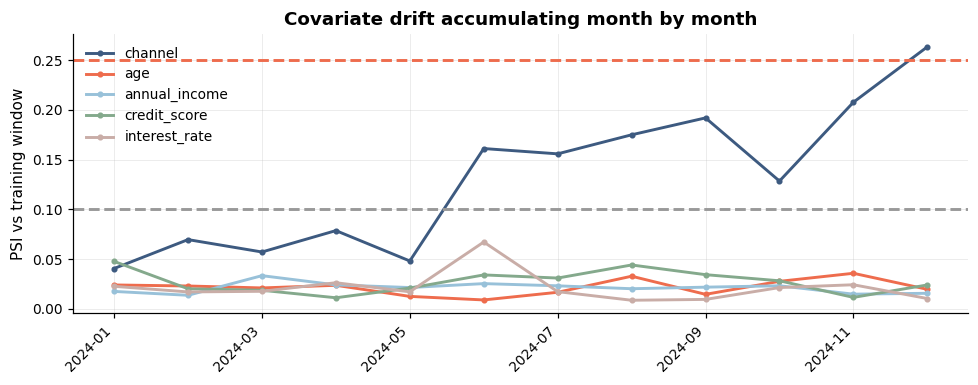

In [12]:
# PSI month by month, so you see drift accumulating rather than discovering it.
future = credit.loc[~train_mask].copy()
monthly_psi = {}
for month, grp in future.groupby("application_month"):
    if len(grp) < 100:
        continue
    monthly_psi[month] = {col: psi(X_train[col], grp[col]) for col in ["channel", "age", "annual_income", "credit_score", "interest_rate"]}
psi_df = pd.DataFrame(monthly_psi).T

fig, ax = plt.subplots(figsize=(9, 3.6))
psi_df.plot(marker="o", ms=3, ax=ax)
ax.axhline(0.1, ls="--", color="0.6")
ax.axhline(0.25, ls="--", color="#ee6c4d")
ax.set(ylabel="PSI vs training window", title="Covariate drift accumulating month by month")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
psi_df.round(3)

In [13]:
# A label-free drift check that needs no per-feature thresholds: can a
# classifier tell training data from production data? If it can, they differ.
from sklearn.model_selection import cross_val_score

combined = pd.concat([X_train.assign(__is_new=0), X_future.assign(__is_new=1)], ignore_index=True)
adv_y = combined.pop("__is_new")

adv_auc = cross_val_score(
    Pipeline([("prep", clone(prep)), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=200))]),
    combined, adv_y, cv=3, scoring="roc_auc", n_jobs=-1,
).mean()
print(f"adversarial validation AUC: {adv_auc:.4f}")
print("0.5 = the two periods are indistinguishable; >0.7 = materially different populations")

adversarial validation AUC: 0.5534
0.5 = the two periods are indistinguishable; >0.7 = materially different populations


**Adversarial validation** is the drift test I reach for first. One number, no
thresholds to argue about, and permutation importance on the discriminator
tells you *which* features moved. It also catches multivariate drift that
per-feature PSI misses entirely — a change in the *relationship* between two
features with both marginals unchanged.

### Concept drift needs labels — and labels are late

,n,auc,brier,mean_predicted,observed_rate
application_month,,,,,
2024-01,398.0,0.8489,0.0685,0.0926,0.0980
2024-02,417.0,0.7806,0.0941,0.0952,0.1247
2024-03,402.0,0.8275,0.0896,0.0964,0.1294
2024-04,428.0,0.7691,0.1063,0.0916,0.1425
2024-05,435.0,0.7377,0.1115,0.0965,0.1356
2024-06,399.0,0.6703,0.1430,0.0944,0.1754
2024-07,442.0,0.7697,0.1071,0.0979,0.1493
2024-08,466.0,0.7409,0.1455,0.1012,0.1910
2024-09,496.0,0.7052,0.1407,0.0991,0.1694


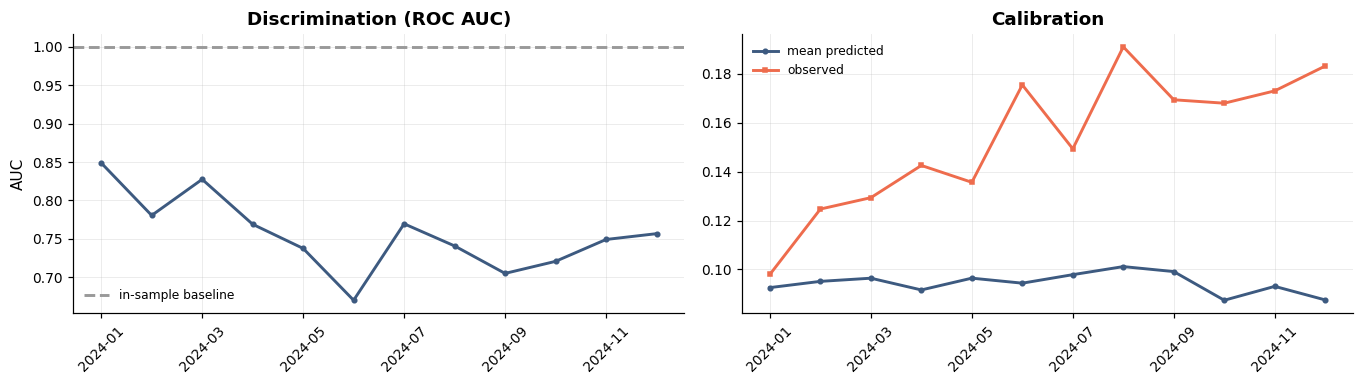

In [14]:
future_scored = future.assign(score=model.predict_proba(X_future)[:, 1])
monthly = future_scored.groupby("application_month").apply(
    lambda g: pd.Series({
        "n": len(g),
        "auc": roc_auc_score(g["default"], g["score"]) if g["default"].nunique() > 1 else np.nan,
        "brier": brier_score_loss(g["default"], g["score"]),
        "mean_predicted": g["score"].mean(),
        "observed_rate": g["default"].mean(),
    }), include_groups=False,
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
axes[0].plot(monthly.index, monthly["auc"], marker="o", ms=3)
axes[0].axhline(roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]), ls="--", color="0.6", label="in-sample baseline")
axes[0].set(title="Discrimination (ROC AUC)", ylabel="AUC"); axes[0].legend(fontsize=8)
axes[1].plot(monthly.index, monthly["mean_predicted"], marker="o", ms=3, label="mean predicted")
axes[1].plot(monthly.index, monthly["observed_rate"], marker="s", ms=3, label="observed")
axes[1].set(title="Calibration"); axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xticks(monthly.index[::2])
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
monthly.round(4)

Read the two panels together. That distinction is the whole diagnosis:

- **Discrimination holds, calibration slips** → the *ranking* is still right,
  the *level* is wrong. Recalibrate (Module 08); a full retrain is overkill.
- **Discrimination degrades** → the relationships changed. Retrain.
- **Neither moves but PSI is high** → the population changed in ways the model
  is robust to. Note it, do not act.

## 6. A monitoring specification

Turn all of the above into something an ops team can run on a schedule.

In [15]:
def monitor(model, reference_X, current_X, current_y=None, baseline=None, threshold=0.13):
    """One scheduled monitoring run. Returns metrics plus triggered alerts."""
    baseline = baseline or {}
    scores = model.predict_proba(current_X)[:, 1]
    drift = drift_report(reference_X, current_X)

    m = {
        "n_scored": len(current_X),
        "mean_score": float(scores.mean()),
        "approval_rate": float((scores < threshold).mean()),
        "score_p99": float(np.quantile(scores, 0.99)),
        "max_psi": float(drift["psi"].max()),
        "features_investigate": list(drift.index[drift["band"] == "INVESTIGATE"]),
    }
    if current_y is not None:                      # only once outcomes mature
        m |= {"roc_auc": float(roc_auc_score(current_y, scores)),
              "brier": float(brier_score_loss(current_y, scores)),
              "observed_rate": float(np.mean(current_y)),
              "calibration_gap": float(scores.mean() - np.mean(current_y))}

    alerts = []
    if m["max_psi"] > 0.25:
        alerts.append(("WARN", f"covariate drift: PSI {m['max_psi']:.3f} on {drift['psi'].idxmax()}"))
    if baseline.get("mean_score") and abs(m["mean_score"] - baseline["mean_score"]) / baseline["mean_score"] > 0.20:
        alerts.append(("WARN", f"mean score moved {m['mean_score'] / baseline['mean_score'] - 1:+.1%} vs baseline"))
    if "roc_auc" in m and baseline.get("roc_auc") and baseline["roc_auc"] - m["roc_auc"] > 0.03:
        alerts.append(("CRIT", f"AUC dropped {baseline['roc_auc'] - m['roc_auc']:.3f} below baseline"))
    if "calibration_gap" in m and abs(m["calibration_gap"]) > 0.02:
        alerts.append(("CRIT", f"calibration gap {m['calibration_gap']:+.4f}"))
    return m, alerts


# The baseline MUST be an out-of-sample estimate. An in-sample AUC on a boosted
# model is close to 1.0, so every production month would look like a catastrophic
# drop and your CRIT alert would fire forever. Cross-validate it.
from sklearn.model_selection import cross_val_predict

oof = cross_val_predict(clone(model), X_train, y_train, cv=5, method="predict_proba", n_jobs=-1)[:, 1]
in_sample = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])

baseline = {"mean_score": float(oof.mean()), "roc_auc": float(roc_auc_score(y_train, oof))}
print(f"in-sample AUC (wrong baseline)      : {in_sample:.4f}")
print(f"cross-validated AUC (right baseline): {baseline['roc_auc']:.4f}")

for label, sl in [("2024 Q1", slice(0, 900)), ("2024 full year", slice(None))]:
    m, alerts = monitor(model, X_train, X_future.iloc[sl], y_future.iloc[sl], baseline)
    print(f"\n=== {label} ===")
    print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in m.items()})
    for sev, msg in alerts or [("OK", "no alerts")]:
        print(f"  [{sev}] {msg}")

in-sample AUC (wrong baseline)      : 0.9998
cross-validated AUC (right baseline): 0.7383

=== 2024 Q1 ===
{'n_scored': 900, 'mean_score': 0.0931, 'approval_rate': 0.8111, 'score_p99': 0.8428, 'max_psi': 0.0474, 'features_investigate': [], 'roc_auc': 0.8125, 'brier': 0.0816, 'observed_rate': 0.1122, 'calibration_gap': -0.0192}
  [OK] no alerts



=== 2024 full year ===
{'n_scored': 5350, 'mean_score': 0.0944, 'approval_rate': 0.8071, 'score_p99': 0.7772, 'max_psi': 0.1194, 'features_investigate': [], 'roc_auc': 0.7491, 'brier': 0.1177, 'observed_rate': 0.1548, 'calibration_gap': -0.0604}
  [CRIT] calibration gap -0.0604


## 7. Retraining strategy

Four options. Pick deliberately, and write the choice down.

| Strategy | Trigger | Good for | Risk |
|---|---|---|---|
| **Scheduled** | calendar (monthly/quarterly) | stable domains, audit-friendly | retrains when nothing changed; misses fast shifts |
| **Triggered** | a monitoring alert | responsive, efficient | alert tuning is its own project; can thrash |
| **Continuous** | every batch, `partial_fit` | high-volume, fast-moving (fraud, ads) | hard to audit; a bad batch propagates immediately |
| **Champion / challenger** | continuous shadow evaluation | regulated environments | costs two pipelines |

In BFSI the answer is nearly always **scheduled with triggered override**,
plus champion/challenger: a fixed cadence for the audit trail, an escape hatch
for shocks, and a challenger scored in shadow so promotion is evidence-based.

The retrain-window question matters more than the cadence:

In [16]:
strategies = {
    "expanding window (all history)": lambda df: df,
    "rolling 18 months": lambda df: df[df["application_month"] >= "2022-07"],
    "rolling 12 months": lambda df: df[df["application_month"] >= "2023-01"],
    "recent 6 months only": lambda df: df[df["application_month"] >= "2023-07"],
}

train_df = credit.loc[train_mask]
rows = []
for name, window in strategies.items():
    sub = window(train_df)
    m = clone(model).fit(sub[FEATURES], sub["default"])
    p = m.predict_proba(X_future)[:, 1]
    rows.append({"training window": name, "n_rows": len(sub),
                 "future_auc": round(roc_auc_score(y_future, p), 4),
                 "future_brier": round(brier_score_loss(y_future, p), 5),
                 "calibration_gap": round(p.mean() - y_future.mean(), 4)})
pd.DataFrame(rows).set_index("training window")

,n_rows,future_auc,future_brier,calibration_gap
training window,,,,
expanding window (all history),6650,0.7491,0.11775,-0.0604
rolling 18 months,5436,0.7454,0.11791,-0.0662
rolling 12 months,3923,0.7447,0.12298,-0.0721
recent 6 months only,2097,0.7265,0.12910,-0.0833


This is the trade every retraining policy is really making: **more data versus
more recent data.** When the world is stationary, more data wins. When it is
drifting, recency wins. Measure it on your own data rather than adopting a
convention — and re-measure it after every regime change, because the answer
moves.

## 8. A serving shape

The scoring path, written out. This is the shape a FastAPI or Flask handler
takes; the framework is the least interesting part.

In [17]:
class ScoringService:
    """Load once, validate every request, score, log everything."""

    def __init__(self, artifact_dir):
        artifact_dir = Path(artifact_dir)
        self.manifest = json.loads((artifact_dir / "manifest.json").read_text())
        self._check_environment()
        self.model = joblib.load(artifact_dir / "model.joblib")
        self.validator = SchemaValidator(self.manifest["schema"], self.manifest["training"]["feature_order"])
        self.threshold = self.manifest["decision"]["threshold"]
        self.log = []

    def _check_environment(self):
        want = self.manifest["environment"]["scikit_learn"]
        if sklearn.__version__ != want:
            # In production: refuse to start. Here: warn, so the notebook runs.
            print(f"WARNING: artefact built with scikit-learn {want}, running {sklearn.__version__}")

    def score(self, payload: pd.DataFrame, request_id="-"):
        t0 = perf_counter()
        check = self.validator.validate(payload)
        if not check["ok"]:
            return {"request_id": request_id, "status": "rejected", "issues": check["issues"]}

        X = payload.reindex(columns=self.manifest["training"]["feature_order"])
        proba = self.model.predict_proba(X)[:, 1]
        decision = np.where(proba >= self.threshold, "decline", "approve")

        record = {
            "request_id": request_id,
            "model_version": self.manifest["version"],
            "n_rows": len(X),
            "latency_ms": round((perf_counter() - t0) * 1000, 3),
            "mean_score": float(proba.mean()),
            "n_declined": int((decision == "decline").sum()),
            "warnings": [i["detail"] for i in check["issues"]],
        }
        self.log.append(record)
        return {"status": "ok", "probability": proba, "decision": decision, "meta": record}


service = ScoringService(WORK / "v1.0.0")
resp = service.score(X_future.head(250), request_id="req-0001")
print({k: v for k, v in resp["meta"].items()})
print("\nfirst five decisions:", list(zip(resp["probability"][:5].round(4), resp["decision"][:5])))

rejected = service.score(broken, request_id="req-0002")
print(f"\nbroken payload -> status={rejected['status']}, "
      f"{len(rejected.get('issues', []))} issue(s), first: {rejected.get('issues', [{}])[0].get('detail', '')[:70]}")

{'request_id': 'req-0001', 'model_version': '1.0.0', 'n_rows': 250, 'latency_ms': 18.664, 'mean_score': 0.08605387595131944, 'n_declined': 39, 'warnings': []}

first five decisions: [(np.float64(0.0851), np.str_('approve')), (np.float64(0.0136), np.str_('approve')), (np.float64(0.0167), np.str_('approve')), (np.float64(0.1179), np.str_('approve')), (np.float64(0.04), np.str_('approve'))]

broken payload -> status=rejected, 3 issue(s), first: missing columns: ['credit_score']


Note what gets logged on every request: model version, latency, score
distribution, decision counts and schema warnings. **That log is your
monitoring dataset.** If you do not log the scores at serving time, you cannot
detect drift later — and this is the single most common gap between an ML
system that is monitored and one that merely has a monitoring plan.

---
## Exercises

### Exercise 13.1 — Break a pickle across versions

In two virtual environments with different scikit-learn versions (e.g. 1.4 and
1.8), save a pipeline in one and load it in the other. Document exactly what
happens for: `StandardScaler`, `OneHotEncoder`, `HistGradientBoostingClassifier`
and a `Pipeline` containing all three.

Then repeat with `skops`. Write the one-page persistence policy you would give
an engineering team, including what to do when a version bump is unavoidable.

In [18]:
# Your code here.

### Exercise 13.2 — Get single-row latency under 1 ms

Starting from the pipeline in this module, reduce single-row `predict_proba`
latency as far as you can. Try: replacing the `ColumnTransformer` with
precomputed index arrays; converting to ONNX; caching the one-hot mapping as a
dict; scoring from a numpy array rather than a DataFrame.

Report latency at each step and confirm predictions stay identical to 1e-9.
Then say which optimisations you would actually keep, given they cost
maintainability.

In [19]:
# Your code here.

### Exercise 13.3 — A drift dashboard

Build `drift_dashboard(reference, stream, freq="M")` producing, for each
period: per-feature PSI, adversarial-validation AUC, prediction-distribution KS
statistic, and — where labels exist — AUC and calibration gap.

Render it as a single HTML page with a traffic-light summary. Run it over the
2024 credit data and identify the earliest period at which a well-designed
alert would have fired. How much earlier is that than the first
label-based signal?

In [20]:
# Your code here.

### Exercise 13.4 — Champion / challenger

Implement a shadow-mode framework: a champion serving decisions, a challenger
scoring the same traffic without acting, and a promotion rule.

Your promotion rule must handle: statistical significance across the shadow
period, the fairness checks from Module 12, a latency budget, and a minimum
observation window. Simulate six months on the credit data with monthly
retrained challengers. How often does your rule promote, and is that too often?

In [21]:
# Your code here.

### Exercise 13.5 — The incident

Simulate this scenario: on 1 March, an upstream change starts sending
`credit_score` in a 0–100 range instead of 300–850 for 30% of applications.
Nobody is told.

1. What happens to the model's predictions and its approval rate?
2. Which of your monitors fires, and how many days later?
3. What is the cost, in the Module 08 cost units, of the delay?
4. Write the post-incident review, including the one control that would have
   caught it on day one.

In [22]:
# Your code here.

---
## Takeaways

- `joblib`/`pickle` executes arbitrary code and couples you to exact library
  versions. Use `skops` across trust boundaries, ONNX across languages, and
  **pin and verify versions either way**.
- Ship a **bundle**, not a file: model, manifest, input schema, environment,
  decision threshold and a reference batch with expected outputs.
- The **input contract** is the model's only defence against upstream change,
  and none of the failures it catches would raise an exception on their own.
- Single-row latency is dominated by fixed overhead, not the model. Micro-batch.
- **Covariate drift is detectable without labels; concept drift is not.** In
  long-outcome domains that gap is measured in years.
- Watch discrimination and calibration separately: calibration slipping alone
  means recalibrate, not retrain.
- **Log scores at serving time.** Without that log there is no monitoring, only
  a monitoring plan.

**Next:** Module 14 — the capstone, where all of this is assembled into one
end-to-end engagement.